In [2]:
!pip install langchain_openai

In [1]:
import langchain


In [2]:
import os
import langchain
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from langchain import chat_models
from getpass import getpass

In [3]:
os.environ["OPENAI_API_KEY"] = getpass()

··········


In [14]:
llm = ChatOpenAI(model="openai/gpt-oss-120b:free",
                 base_url="https://openrouter.ai/api/v1",
                 api_key=os.getenv("OPENAI_API_KEY"))

In [5]:
os.environ["TAVILY_API_KEY"] = getpass()

··········


In [6]:
!pip install tavily-python

In [7]:
from tavily import TavilyClient

tavily_client = TavilyClient(api_key= os.getenv("tavily_api_key"))

In [8]:
def web_search(query:str ,max_results:int = 5, include_raw_content:bool = False):
    "Web Search Agent"
    return tavily_client.search(query,max_results=max_results,include_raw_content=include_raw_content)


In [14]:
!pip install deepagents

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 186.3/186.3 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.4/50.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.3/393.3 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 662.1/662.1 kB 23.9 MB/s eta 0:00:00
  Attempting uninstall: langsmith
    Found existing installation: langsmith 0.7.34
    Uninstalling langsmith-0.7.34:
      Successfully uninstalled langsmith-0.7.34


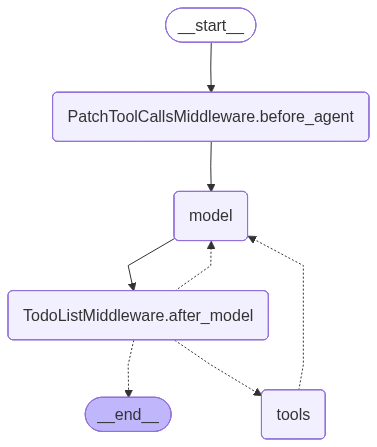

In [18]:
from deepagents import create_deep_agent
deepagent=create_deep_agent(
    model=llm,
    # llm,

                  tools=[web_search],
                  system_prompt="Act as a job searcher.")
deepagent

In [22]:
response = deepagent.invoke({"messages": [{"role":"user","content":"what is datascience."}]})
response

{'messages': [HumanMessage(content='what is datascience.', additional_kwargs={}, response_metadata={}, id='f70827ac-bc98-4398-a483-b19378089340'),
  AIMessage(content='Data science is an interdisciplinary field that extracts insights and knowledge from data using a blend of statistics, computer science, and domain expertise. It involves collecting, cleaning, analyzing, and visualizing data, as well as building predictive models and algorithms to support decision‑making and solve complex problems.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 71, 'prompt_tokens': 5404, 'total_tokens': 5475, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 7, 'rejected_prediction_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 80, 'cache_write_tokens': 0, 'video_tokens': 0}, 'cost': 0, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 0, 'up

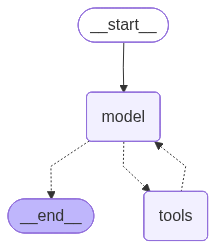

In [25]:
simple_agent = create_agent(model=llm, tools=[web_search])
simple_agent

In [24]:
simple_response = simple_agent.invoke({"messages": [{"role":"user","content":"what is datascience."}]})
simple_response

{'messages': [HumanMessage(content='what is datascience.', additional_kwargs={}, response_metadata={}, id='32d59ccf-15c4-42f8-9a10-315de43f4bf0'),
  AIMessage(content='**Data science** is an interdisciplinary field that turns raw data into actionable knowledge. It blends elements of statistics, computer science, mathematics, domain expertise, and often aspects of engineering and visualization to:\n\n1. **Collect** data from various sources (databases, APIs, sensors, web scraping, etc.).\n2. **Clean and preprocess** it—handling missing values, errors, inconsistent formats, and scaling.\n3. **Explore and visualize** the data to discover patterns, trends, and anomalies.\n4. **Model** the data using statistical methods, machine‑learning algorithms, or deep‑learning networks to make predictions, classify items, or uncover hidden structures.\n5. **Interpret** the results, assess model performance, and translate findings into clear, actionable insights for decision‑makers.\n6. **Deploy** mode